# 1章 コンピュータネットワークの基本要素

コンピュータネットワークは、複数のコンピュータやデバイスが互いに通信するためのシステムです。このネットワークを構成するためには、いくつかの基本要素が必要です。以下に、コンピュータネットワークの主要な基本要素について解説します。

## ノード
### コンピュータネットワークにおけるノード

コンピュータネットワークにおいて、ノードは非常に重要な役割を果たします。
ノードはネットワーク内の各端末やデバイスを指します。
これには個人のコンピュータ、スマートフォン、タブレットなどのエンドユーザデバイス、ルーターやスイッチなどのネットワーク機器、そしてサーバなどの強力なコンピュータが含まれます。
これらのノードは、情報の生成、受信、送信を行い、コンピュータシステム上でのデータの共有を可能にします。

ノードは通常、一意の識別子であるIPアドレスやMACアドレスによって識別されます。
これにより、ネットワーク内での個々のノードの特定と通信が可能になります。
ノードは、有線（例えば、イーサネットケーブル）または無線（例えば、空気中を伝わる電波）などの媒体（メディア）を介して相互に接続されます。

現代のインターネットは非常に大きなコンピュータネットワークであり、膨大な数のノードから構成されています。
逆に言えば、様々なデバイスが一つの大きなネットワークへと接続することで、今日のインターネットが形成されているとも考えられます。
このように、ノードの理解は、コンピュータネットワークの基本的な概念を学ぶ上で非常に重要です。
ノードは、ネットワークの「ビルディングブロック（構成単位）」として、通信の効率性、安全性、拡張性に直接的な影響を与えます。


### `Node`クラスの設計方針
コンピュータネットワークについて学習を進めていくために、まずはノードを表現するクラスを作成します。
先述した通り、ノードはネットワーク内のコンピュータやサーバ、ルータなどのデバイスや端末を指します。
ノードはそれぞれ、ネットワーク内で一意のアドレスや識別子を持つことで識別され、他のノードとデータを交換することができます。
ネットワーク内の通信は、これらのノード間のデータ転送によって成立します。

`Node`クラスの主な目的は、コンピュータネットワーク内でのデバイスや端末の動作をモデル化することにあります。
つまり、シミュレーション上で実際のネットワークの動作を理解しやすくするために、 `Node`クラスを使用してネットワークを構成するデバイスを抽象的に表現します。
これにより、データの送受信、ネットワークのトポロジ、ルーティングの挙動などを視覚化し、理解を深めることができます。

ただし、近年のデバイスは非常に多くの機能を搭載しており、その動作を理解するのは大変です。
本書は初学者を対象としているので、まずは最低限の基本的な機能（ノードの識別、シンプルな1対1接続、パケット送受信）から実装していきます。
Nodeクラスは、なるべく現実のネットワークの挙動を正確に模倣できるように、現実のネットワークデバイスの特性や挙動を反映しつつ、拡張性と柔軟性に重点を置いて設計しています。
その上で、章を進めるにつれて、徐々に複雑な機能（スイッチング、ルーティング、異なるプロトコルのサポートなど）を追加していきます。

### `Node`クラスの実装
`Node`クラスはコンピュータネットワークの基本的な要素であるノードを表現するために設計されたPythonクラスです。
このクラスは、ネットワーク内の各ノードをプログラムで扱うための基本的な機能を提供します。
ノードとは、コンピュータ、スイッチ、ルータなど、ネットワーク内の任意のデバイスを指します。
ここで実装する`Node`クラスの主要な機能と特性は以下の通りです：

- **ノードID (`node_id`)**: これは、シミュレータ上でノードを識別するための名前です。各ノードには固有のIDを割り当てることとします。

- **アドレス (`address`)**: ノードの住所に当たる情報です。手紙を送ったり受け取ったりする際に用いる住所と同じようなものです。実際にはいくつかの書き方が規定されているのですが、簡単のため本章では簡易的な書き方をします。

- **リンクのリスト (`links`)**: ノードに接続されているリンクのリストを保持します。リンクはノード間の物理的または論理的な接続を表し、ネットワークの構造と通信経路を形成します。詳しくは後で扱います。

`__init__`メソッドはクラスのコンストラクタであり、ノードIDとアドレスを引数として受け取り、これらの値をインスタンス変数に設定します。また、ノードに接続されたリンクのリストを初期化する役割も担っています。

`__str__`メソッドはノードの文字列表現を提供し、主にノードのIDとアドレスを含む文字列を返します。このメソッドはノードの情報を簡潔に表示し、ネットワークのトポロジを理解する際に便利です。

以下では実際の使用例として、2つのノード（`node1`と`node2`）が作成され、それぞれに異なるIDとアドレスが割り当てられています。
これらのノードは、`print`関数を使用して詳細を表示することができ、ネットワーク内での役割や位置を容易に理解することができます。


In [ ]:
class Node:
    def __init__(self, node_id, address=None):
        """
        ネットワーク内のノードを表すNodeクラス

        :param node_id: ノードの一意の識別子
        :param address: ノードの簡易アドレス
        :param links: ノードに接続されたリンク
        """
        self.node_id = node_id
        self.address = address
        self.links = []

    def __str__(self):
        return f"ノード(ID: {self.node_id}, アドレス: {self.address})"

# 2つのノードを作成
node1 = Node(node_id=1, address="00:01")
node2 = Node(node_id=2, address="00:02")

# ノードの詳細を表示
print(node1)
print(node2)


ノード(ID: 1, アドレス: 00:01)
ノード(ID: 2, アドレス: 00:02)


## リンク
### コンピュータネットワークにおけるリンク
コンピュータネットワークにおけるリンクは、ネットワーク内のノード（コンピュータ、デバイスなど）間の接続を表します。
リンクはネットワークの基本構造の一部であり、ノード間でのデータ転送を可能にする重要な役割を担っています。
ノード間をリンクで接続することで、はじめてネットワークが構成されるのです。

物理的には、リンクには主に二つの種類があります。
つまりイーサネットケーブルや光ファイバなどによってノード間を結ぶ有線接続と、Wi-FiやBluetoothなどに代表される無線接続です。
一般的に、物理的に接続する有線リンクは安定性と高速なデータ転送を提供することが多いです。
無線リンクは柔軟性が高く、物理的な配線を必要としないため、設置が容易ですが、場合によっては物理的リンクよりも速度が低下したり、干渉の影響を受けやすい場合があります。

リンクの特性は、帯域幅（データ転送速度）、遅延（データ転送にかかる時間）、信頼性などによって決まります。
帯域幅が高いリンクは、一定時間内により多くのデータを転送でき、遅延が少ないリンクはデータの到達時間が短くなります。
信頼性は、リンクがどれだけ安定してデータ転送を行えるかを示します。
信頼性の低いリンクは、データの損失やエラーが発生しやすいです。

リンクはネットワーク設計において重要な要素であり、適切なリンクの選択と配置は、ネットワークの全体的なパフォーマンスと効率に大きな影響を与えます。
例えば、データセンタのような高速で大容量のデータ転送が必要な環境では、高帯域幅の物理的リンクが好まれることがあります。
一方、オフィス環境や家庭内ネットワークでは、設置の容易さや柔軟性から無線リンクがよく使われます。


### `Link`クラスの設計方針
`Link`クラスの目的は、ネットワーク内のノード間の接続をモデル化し、その特性を表現することにあります。
あくまでシミュレーションなので、有線・無線などの媒体を問わず、あるノードと別のノードが抽象的にリンクで接続されるものと捉えます。
設計としては、理解しやすさのためノード間をシンプルに1対1で接続するものとします。
速度や伝搬距離、信頼性などといったリンクの特性については、リンククラスのパラメタとして設定できるようにしておきます。
ただし、そのようなパラメタについて詳しくは次章で扱うこととします。

ノードとリンクを用いることで、様々なネットワークの構成（トポロジと呼びます）を柔軟に表現できます。
例えば、星形となるスター、円形となるリング、全ノードを相互接続するメッシュなどの異なるトポロジを、簡単に模擬することができます。
ただし、本章で実装する範囲では、1対1での通信しかできない点には留意してください。
ノードやリンクの機能を拡張することで、多くのノードとリンクから構成される本格的なネットワークの動作をテストすることができます。

### `Link`クラスの実装
`Link`クラスは、コンピュータネットワークにおけるリンクの概念をプログラムで表現するために設計されています。
リンクとは、ネットワーク内の2つのノード間の物理的または論理的な接続を指し、データの転送経路を提供します。
このクラスは、リンクの特性を詳細に定義し、ネットワークの構造と性能を理解するための重要なツールとなります。

- **ノード間の接続**: `Link`クラスは2つのノード（`node_x`と`node_y`）を引数として受け取り、これらのノード間を接続します。この接続は、ネットワーク内のデータ転送経路を形成します。

- **帯域幅 (`bandwidth`)**: リンクの帯域幅は、そのリンクを通じて単位時間あたりに転送できるデータ量を表します。この値が大きいほど、より多くのデータを迅速に転送できます。

- **遅延 (`delay`)**: リンクの遅延は、データがリンクを通過するのに要する時間を指します。遅延が長いと、データ転送に時間がかかります。

- **パケットロス率 (`packet_loss`)**: リンク上でのパケットロス率は、データ転送中に失われるパケットの割合を表します。この値が高いと、信頼性の低い接続となります。

- **リンクの追加**: コンストラクタ内で、`node_x`と`node_y`の両ノードに対してリンクを追加します。これにより、ノード間の接続状態が自動的に更新されます。

#### `__str__`メソッド
`__str__`メソッドはリンクの文字列表現を提供し、リンクが接続するノードのID、帯域幅、遅延、パケットロス率を含む情報を表示します。このメソッドはリンクの特性を簡単に確認するために有用です。

### `Node`クラスへのリンク接続機能の追加
上記の中で、リンクの追加という概念が出てきました。
これはすなわち、2つのノードを、リンクで接続するという意味です。
リンクを宣言した際に、ノード側で自動的にリンクを認識できるように`Node`クラスをアップデートします。
追加、修正するメソッドは以下です。

#### `add_link`メソッド
`add_link`メソッドは、ノードに新しいリンクを追加するために使用されます。
このメソッドは、リンクが既にノードのリンクリストに存在しない場合にのみ、そのリンクをリストに追加します。
このメソッドにより、ノード間の物理的または論理的な接続を動的に管理できます。
ネットワークトポロジの変更や更新時に、ノードの接続状態を簡単に調整することが可能になります。

#### `__str__`メソッド
ノードのIDとアドレスに加えて、ノードに接続されている他のノードのIDのリストを含む文字列を返すようにします。
このメソッドにより、ノードのネットワーク内での位置と接続状態を直感的に把握できます。
ネットワークのトポロジ分析やデバッグ時に、どのノードがどのノードに直接接続されているかを簡単に確認することができます。


In [ ]:
class Node:
    def __init__(self, node_id, address=None):
        self.node_id = node_id
        self.address = address
        self.links = []

    # リンクを接続するメソッドを追加
    def add_link(self, link):
        if link not in self.links:
            self.links.append(link)

    # ノードの文字列表現を返すように修正
    def __str__(self):
        connected_nodes = [link.node_x.node_id if self != link.node_x else link.node_y.node_id for link in self.links]
        connected_nodes_str = ', '.join(map(str, connected_nodes))
        return f"ノード(ID: {self.node_id}, アドレス: {self.address}, 接続: {connected_nodes_str})"

class Link:
    def __init__(self, node_x, node_y, bandwidth=10000, delay=0.001, packet_loss=0.0):
        """
        ネットワーク内の2つのノード間のリンクを表すLinkクラス。

        :param node_x: リンクの一方のノード。
        :param node_y: リンクのもう一方のノード。
        :param bandwidth: リンクの帯域幅（データ転送速度）。デフォルトは1。
        :param delay: リンクの遅延時間。デフォルトは0。
        :param packet_loss: リンクのパケットロス率（0.0から1.0の範囲）。デフォルトは0.0。
        """
        self.node_x = node_x
        self.node_y = node_y
        self.bandwidth = bandwidth
        self.delay = delay
        self.packet_loss = packet_loss

        # ノードに対して、リンクを接続
        node_x.add_link(self)
        node_y.add_link(self)

    def __str__(self):
        return f"リンク({self.node_x.node_id} ↔ {self.node_y.node_id}, 帯域幅: {self.bandwidth}, 遅延: {self.delay}, パケットロス率: {self.packet_loss})"

# 例: ノード1とノード2をリンクで接続する
node1 = Node(node_id=1, address="00:01")
node2 = Node(node_id=2, address="00:02")
link = Link(node1, node2)

# ノードとリンクの詳細を表示
print(node1)
print(node2)
print(link)


ノード(ID: 1, アドレス: 00:01, 接続: 2)
ノード(ID: 2, アドレス: 00:02, 接続: 1)
リンク(1 ↔ 2, 帯域幅: 1, 遅延: 0, パケットロス率: 0.0)


## パケット
### コンピュータネットワークにおけるパケット
コンピュータネットワークにおいて、パケットはデータ通信の基本的な単位です。
パケットは、ネットワークを介して送信されるデータの小さな断片であり、手紙や小包のようなものとしてイメージできます。
各パケットはペイロード（実際に送信される情報）、ヘッダ（送信元と宛先のアドレス、サイズ、順序などの制御情報を含む）、そして場合によってはフッタ（転送の整合性を確認するための情報）を含みます。
ペイロードとヘッダの関係は、郵送する荷物と、表面に貼られる荷札の関係と同様です。

インターネットにおいて、ありとあらゆるデータはパケットという単位で転送されます。
動画などの大容量のデータでも、その転送単位はパケットです。
データをパケットに分割して運ぶことで、多くのユーザ、多くのデバイスの通信を効率的にさばくことができます。
また、ネットワーク上でのエラーの検出と修正、信頼性の高いデータ転送が可能になります。
さらに、パケットのヘッダ情報はネットワーク上でのルーティング（データの最適な経路選択）に不可欠であり、ネットワークの柔軟性と耐障害性を向上させます。
こうした性質については、後の章で実装しながら確認していきます。

パケットベースの通信はネットワークのスケーラビリティ（拡張性）にも寄与し、多様なデバイスとの互換性を提供します。
このように、パケットはネットワーク通信の効率性、安全性、拡張性に直接的な影響を与えるため、その概念の理解はネットワークの基礎学習において非常に重要です。


### `Packet`クラスの設計方針
`Packet`クラスの主な目的は、ネットワークを通じたデータの伝送プロセスをモデル化し、シミュレーションすることにあります。
このクラスを通じて、ネットワークを介したデータの送受信のプロセスを理解していきます。
Packetクラスの設計は、現実のネットワークのパケット転送時の処理のコア部分を模擬することに重点を置いています。
これには、パケット内のデータ（ペイロード）、送信元と目的地のアドレス、パケットサイズ、および順序などの情報が含まれます。
ただし、本章ではまずシンプルに最小限の情報のみを実装し、後の章で拡張していきます。

### `Packet`クラスの実装
`Packet`クラスは、コンピュータネットワークにおけるデータ通信の基本単位であるパケットを表現するために設計されたPythonクラスです。
その主要な機能と特性は以下の通りです。

- **送信元 (`source`)**: この属性は、パケットが生成されるノードのアドレスを表します。送信元アドレスは、パケットがどこから来たのかを示すために使用されます。

- **宛先 (`destination`)**: この属性は、パケットが送信されるノードのアドレスを指します。宛先アドレスは、ネットワーク上でパケットが到達すべき最終的な目的地を示します。

- **ペイロード (`payload`)**: ペイロードは、パケットに含まれる実際のデータです。実際には0と1のビット列へと変換（符号化）されて転送されますが、ここでは簡単のため文字列などをそのまま扱うこととします。

#### `__str__`メソッド
- `__str__`メソッドは、パケットの文字列表現を提供します。このメソッドはパケットの送信元、宛先、およびペイロードを含む文字列を返し、パケットの内容を簡単に確認することができます。


In [ ]:
class Packet:
    def __init__(self, source, destination, payload):
        """
        ネットワーク内で送信されるパケットを表すPacketクラス。

        :param source: パケットの送信元ノードのアドレス。
        :param destination: パケットの宛先ノードのアドレス。
        :param payload: パケットに含まれるデータ（ペイロード）。
        """
        self.source = source
        self.destination = destination
        self.payload = payload

    def __str__(self):
        return f"パケット(送信元: {self.source}, 宛先: {self.destination}, ペイロード: {self.payload})"


## パケット転送
### パケット転送機能とは
パケットを定義したところで、先ほど作成したノードおよびリンクのクラスに対して、パケット転送機能を追加していきます。
この機能は、ネットワーク内でのデータの流れを表現し、現実のネットワーク通信の基本的なプロセスを模倣するために必要です。
つまり、コンピュータネットワークでは、ノード（コンピュータ、ルータ、スイッチなど）が互いにデータをやり取りします。
パケット送受信機能は、このデータ交換をシミュレートするために必要です。
また、それを通じて、ネットワークの基本的な動作原理を学習することができます。
例えば、データのルーティング、パケットの処理、ネットワークの遅延やパケットロスの影響などを観察することが可能です。

### `Node`クラスへのパケット送受信機能の追加
`Node`クラスに新たに`send_packet`と`receive_packet`のメソッドを追加します。
これらは、ネットワーク内でのパケットの送受信プロセスをシミュレートするための機能です。
これらのメソッドは、ノードがネットワーク内でデータをどのように処理し、転送するかを表現します。

#### `send_packet`メソッド
`send_packet`メソッドは、ノードがパケットを送信する際に使用されます。
ノードに接続されたリンクを介して、パケットを次のノードに転送します。

#### `receive_packet`メソッド
`receive_packet`メソッドは、ノードがパケットを受信する際に使用されます。
このメソッドは、受信したパケットについて表示するだけのシンプルなものです。


In [ ]:
class Node:
    def __init__(self, node_id, address=None):
        self.node_id = node_id
        self.address = address
        self.links = []

    def add_link(self, link):
        if link not in self.links:
            self.links.append(link)

    # パケットを送信するメソッドを追加
    def send_packet(self, packet):
        if packet.destination == self.address:
            self.receive_packet(packet)
        else:
            for link in self.links:
                next_node = link.node_x if self != link.node_x else link.node_y
                print(f"ノード{self.node_id}からノード{next_node.node_id}へパケット転送")
                link.transfer_packet(packet, self)
                break

    # パケットを受信するメソッドを追加
    def receive_packet(self, packet):
        print(f"ノード{self.node_id}がパケットを受信: {packet.payload}")

    def __str__(self):
        connected_nodes = [link.node_x.node_id if self != link.node_x else link.node_y.node_id for link in self.links]
        connected_nodes_str = ', '.join(map(str, connected_nodes))
        return f"ノード(ID: {self.node_id}, アドレス: {self.address}, 接続: {connected_nodes_str})"


### `Link`クラスへのパケット転送機能の追加
`Link`クラスに新たに追加された`transfer_packet`メソッドは、ネットワーク上でのパケット転送のメカニズムをシミュレートするための機能を提供します。
このメソッドは、パケットを受け取り、それをリンクの他端にあるノードに渡します。
すなわち、リンクを介してパケットを次のノードに転送するために使用されます。
`transfer_packet`メソッドの追加により、`Link`クラスはネットワーク内でのデータ転送を表現することができます。


In [ ]:
class Link:
    def __init__(self, node_x, node_y, bandwidth=1, delay=0, packet_loss=0.0):
        self.node_x = node_x
        self.node_y = node_y
        self.bandwidth = bandwidth
        self.delay = delay
        self.packet_loss = packet_loss

        node_x.add_link(self)
        node_y.add_link(self)

    # 次のノードへパケットを渡すメソッドを追加
    def transfer_packet(self, packet, from_node):
        next_node = self.node_x if from_node != self.node_x else self.node_y
        next_node.receive_packet(packet)

    def __str__(self):
        return f"リンク({self.node_x.node_id} ↔ {self.node_y.node_id}, 帯域幅: {self.bandwidth}, 遅延: {self.delay}, パケットロス率: {self.packet_loss})"


### パケット転送のテスト
以下のコードは、2つのノード間でのパケット送受信をシミュレートするためのものです。
このシミュレーションでは、ノード1からノード2への簡単なメッセージ転送を行います。
以下に、シミュレーションの各ステップとその目的について詳しく解説します。

#### ノードとリンクの設定
1. **ノードの作成**:
   - 2つのノード、`node1`と`node2`が作成されます。それぞれには一意のID（1と2）とアドレス（"00:01"と"00:02"）が割り当てられています。

2. **リンクの作成**:
   - `link1`というリンクが作成され、`node1`と`node2`を接続します。
   - リンクには、帯域幅（`bandwidth`）、遅延時間（`delay`）、パケットロス率（`packet_loss`）が設定されています。これにより、リアルなネットワーク環境を模擬できますが、本章ではまだ使いません。

#### パケットの作成と送信
- `node1`から`node2`へのメッセージ「Hello, Node 2!」を含むパケットが作成されます。
- このパケットは、`node1`のアドレスから`node2`のアドレスへ送信されるよう設定されています。
- `node1`はこのパケットをネットワーク上で送信します。

#### シミュレーションの結果
- **パケット転送**: パケットは`node1`から`node2`へ転送されます。
- **パケット受信**: `node2`はパケットを受信し、そのペイロードを処理します。この例では、`node2`が「Hello, Node 2!」というメッセージを受信します。


In [ ]:
# ノードとリンクの設定
node1 = Node(node_id=1, address="00:01")
node2 = Node(node_id=2, address="00:02")

link1 = Link(node1, node2)

# パケットの作成と送信
packet = Packet(source=node1.address, destination=node2.address, payload="Hello, Node 2!")
node1.send_packet(packet)


ノード1からノード2へパケット転送
ノード2がパケットを受信: Hello, Node 2!


### 課題
1. ノード2からノード1に対して、任意のメッセージを記載したパケットを送信してみましょう。
2. ノード1からノード2に対して、任意のメッセージを記載したパケットを10個送信してみましょう。


In [ ]:
# 課題1: ノード2からノード1に対して、任意のメッセージを記載したパケットを送信
packet_to_node1 = Packet(source=node2.address, destination=node1.address, payload="Hello, Node 1 from Node 2!")
node2.send_packet(packet_to_node1)

# 課題2: ノード1からノード2に対して、任意のメッセージを記載したパケットを10個送信
for i in range(10):
    packet_to_node2 = Packet(source=node1.address, destination=node2.address, payload=f"Message {i+1} from Node 1 to Node 2")
    node1.send_packet(packet_to_node2)

ノード2からノード1へパケット転送
ノード1がパケットを受信: Hello, Node 1 from Node 2!
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 1 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 2 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 3 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 4 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 5 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 6 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 7 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 8 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 9 from Node 1 to Node 2
ノード1からノード2へパケット転送
ノード2がパケットを受信: Message 10 from Node 1 to Node 2


## 可視化
### ネットワークの可視化の意義
ここまでの実装で、無事に2つのノードをリンクで接続し、パケットを1つ送受信することができました。
ただその結果としては、ログが2行出力されただけで、あまり実感が湧かない面もあります。
もちろん、ログをもっと詳細に出力するように実装することも可能なのですが、あまりログが多くなると、読み取るのが大変になります。

そもそもネットワークの学習が難しい要因の一つが、そのブラックボックス性です。
複数のノードが繋がって大きなシステムが構成されるため、その全体像を把握するのが難しくなります。
また、その中で何が起こっているのかを把握することも容易ではありません。
例えば、あるノードから別のノードに向けて送信されたパケットが届かないとき、そのパケットがどこで失われたのかを特定することなども、そんなに簡単なことではありません。

そのような様々なブラックボックス性をもったネットワークについて、本書ではシミュレーションという形で少しずつ解き明かしながら理解を進めていきます。
ここではまず、ネットワークの物理的な構成すなわちトポロジの可視化をできるようにしていきましょう。

### ネットワークトポロジの可視化
コンピュータネットワークのトポロジを視覚的に表現し、分析するために`NetworkGraph`クラスを作成します。
このクラスは、NetworkXライブラリを使用してネットワークのグラフを作成し、ノードとリンク間の関係を可視化します。
ネットワークのトポロジを可視化することで、ネットワーク構造の理解を深め、設計やトラブルシューティングを助けます。

#### `NetworkGraph`クラスの主要な機能と特性
- **グラフの初期化**: `__init__`メソッドで、ネットワークXのグラフオブジェクトを初期化します。このグラフは、ノードとリンクの情報を格納するための基盤となります。

- **ノードの追加**: `add_node`メソッドは、グラフに新しいノードを追加するために使用されます。このメソッドはノードIDとラベルを引数として受け取り、グラフにノードを追加します。

- **リンクの追加**: `add_link`メソッドは、グラフに新しいリンク（エッジ）を追加するために使用されます。このメソッドは2つのノードIDとリンクのラベルを引数として受け取り、これらのノード間にリンクを追加します。

- **グラフの描画**: `draw`メソッドは、グラフの現在の状態を描画して表示します。このメソッドは、ノードとリンクの配置、色、サイズを設定し、ラベルを適切に表示します。

なお、ノードやリンクの宣言時にグラフに追加されるように、`Node`クラスおよび`Link`クラスを少しずつアップデートしています。
ネットワークの可視化は、ネットワークのパフォーマンスのボトルネックを特定するのに役立つだけでなく、ネットワークの拡張や改善の計画を立てる際の助けとなります。
ただし、まだ受け取ったパケットを次のノードに転送する機能（ルーティングやブリッジングの機能）を実装していないため、他のノードを経由したパケット転送は実行できない点には留意する必要があります。

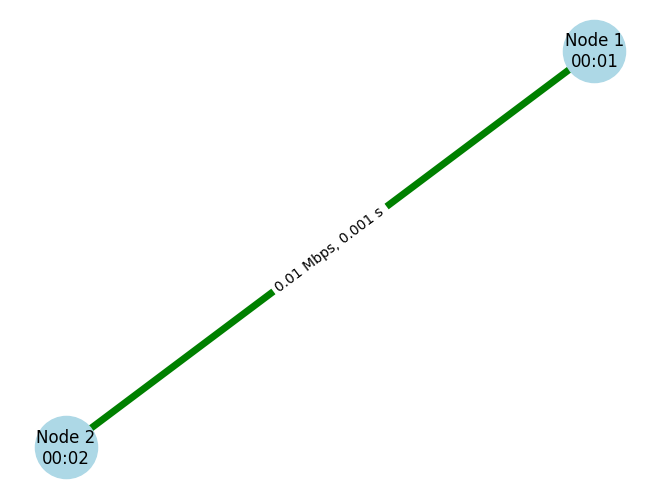

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

class NetworkGraph:
    def __init__(self):
        self.graph = nx.Graph()

    def add_node(self, node_id, label):
        self.graph.add_node(node_id, label=label)

    def add_link(self, node1_id, node2_id, label, bandwidth, delay):
        self.graph.add_edge(node1_id, node2_id, label=label, bandwidth=bandwidth, delay=delay)

    def draw(self):
        # リンクの帯域幅に基づいて線の太さを決定する関数
        def get_edge_width(bandwidth):
            return np.log10(bandwidth) + 1  # bps単位での対数スケール

        # リンクの遅延に基づいて線の色を決定する関数
        def get_edge_color(delay):
            if delay <= 0.001:  # 1ms以下
                return 'green'
            elif delay <= 0.01:  # 1-10ms
                return 'yellow'
            else:  # 10ms以上
                return 'red'

        pos = nx.spring_layout(self.graph)
        edge_widths = [get_edge_width(self.graph[u][v]['bandwidth']) for u, v in self.graph.edges()]
        edge_colors = [get_edge_color(self.graph[u][v]['delay']) for u, v in self.graph.edges()]

        nx.draw(self.graph, pos, with_labels=False, node_color='lightblue', node_size=2000, width=edge_widths, edge_color=edge_colors)
        nx.draw_networkx_labels(self.graph, pos, labels=nx.get_node_attributes(self.graph, 'label'))
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=nx.get_edge_attributes(self.graph, 'label'))
        plt.show()

class Node:
    def __init__(self, node_id, address, network_graph):
        self.node_id = node_id
        self.address = address
        self.links = []
        self.network_graph = network_graph

        # グラフにノードを追加
        label = f'Node {node_id}\n{address}'
        self.network_graph.add_node(node_id, label)

    def add_link(self, link):
        if link not in self.links:
            self.links.append(link)

    def send_packet(self, packet):
        if packet.destination == self.address:
            self.receive_packet(packet)
        else:
            for link in self.links:
                next_node = link.node_x if self != link.node_x else link.node_y
                print(f"ノード{self.node_id}からノード{next_node.node_id}へパケット転送")
                link.transfer_packet(packet, self)
                break

    def receive_packet(self, packet):
        print(f"ノード{self.node_id}がパケットを受信: {packet.payload}")

    def __str__(self):
        connected_nodes = [link.node_x.node_id if self != link.node_x else link.node_y.node_id for link in self.links]
        connected_nodes_str = ', '.join(map(str, connected_nodes))
        return f"ノード(ID: {self.node_id}, アドレス: {self.address}, 接続: {connected_nodes_str})"

class Link:
    def __init__(self, node_x, node_y, network_graph, bandwidth=10000, delay=0.001, packet_loss=0.0):
        self.node_x = node_x
        self.node_y = node_y
        self.bandwidth = bandwidth
        self.delay = delay
        self.packet_loss = packet_loss
        self.network_graph = network_graph

        node_x.add_link(self)
        node_y.add_link(self)

        # グラフにリンクを追加
        label = f'{bandwidth/1000000} Mbps, {delay} s'
        self.network_graph.add_link(node_x.node_id, node_y.node_id, label, self.bandwidth, self.delay)

    def transfer_packet(self, packet, from_node):
        next_node = self.node_x if from_node != self.node_x else self.node_y
        next_node.receive_packet(packet)

    def __str__(self):
        return f"リンク({self.node_x.node_id} ↔ {self.node_y.node_id}, 帯域幅: {self.bandwidth}, 遅延: {self.delay}, パケットロス率: {self.packet_loss})"

class Packet:
    def __init__(self, source, destination, payload):
        self.source = source
        self.destination = destination
        self.payload = payload

    def __str__(self):
        return f"パケット(送信元: {self.source}, 宛先: {self.destination}, ペイロード: {self.payload})"

# ネットワークグラフのインスタンスを作成
network_graph = NetworkGraph()

# ノードとリンクの宣言
node1 = Node(node_id=1, address="00:01", network_graph=network_graph)
node2 = Node(node_id=2, address="00:02", network_graph=network_graph)
link1 = Link(node1, node2, network_graph=network_graph)

# グラフを描画
network_graph.draw()


### 課題
1. node3を作成して、いずれかのノードと接続し，可視化してみましょう。
2. さらにnode4を作成して、いずれかのノードと接続し，可視化してみましょう。


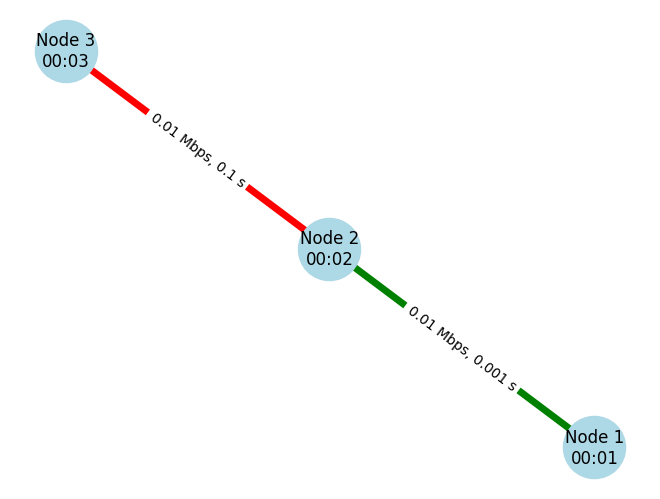

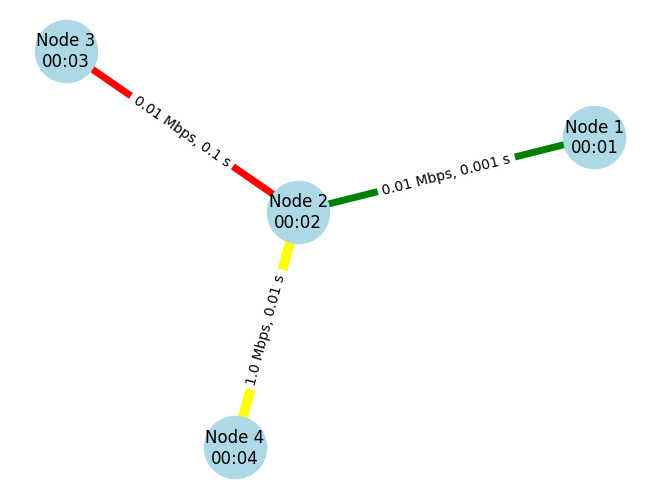

In [ ]:
# 1. node3を作成して、いずれかのノードと接続し，可視化してみましょう。
node3 = Node(node_id=3, address="00:03")
link2 = Link(node2, node3, delay=0.1)
network_graph.draw()

# 2. さらにnode4を作成して、いずれかのノードと接続し，可視化してみましょう。
node4 = Node(node_id=4, address="00:04")
link3 = Link(node2, node4, bandwidth=1000000, delay=0.01)
network_graph.draw()


## 演習課題

本章で作成したクラスをインポートして利用する場合には、以下のように記述・実行してください。
```
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
```
```
from sec1.NetworkGraph import NetworkGraph
from sec1.Node import Node
from sec1.Link import Link
from sec1.Packet import Packet
```

### 演習課題1: 簡単なネットワークの構築と可視化
**目的**: 2つのノードと1つのリンクを使ってネットワークを構築し、そのトポロジを可視化する。

**手順**:
1. 2つのノード（Nodeクラスのインスタンス）を作成する。
2. ノード間を接続するリンク（Linkクラスのインスタンス）を作成する。
3. 構築したネットワークをグラフとして可視化する。

### 演習課題2: パケットの送受信
**目的**: 作成したネットワーク上でパケットを送受信し、そのプロセスを確認する。

**手順**:
1. パケット（Packetクラスのインスタンス）を作成する。
2. 一方のノードから他方のノードへパケットを送信する。
3. 受信したノードがパケットを正しく受信したことを確認する。

### 演習課題3: ネットワークの拡張
**目的**: 複数のノードとリンクを使用して、より複雑なネットワークを構築する。

**手順**:
1. 3つ以上のノードと複数のリンクを使ってネットワークを構築する。
2. 構築したネットワークのトポロジを可視化する。


## 本章のまとめ
本章では、コンピュータネットワークを構成する基本要素であるノード、リンク、パケットについて学びました。
これらの3要素に関する基本的なクラスを実装し、ノード同士をリンクで接続して任意のネットワークを構成できるようにしました。
またパケットを定義し、あるノードからリンクを介して接続されたノードに対してパケットを送受信可能としました。
また、構成したネットワークをグラフとして可視化し、そのトポロジを確認できるようになりました。
ただし、まだパケットを中継する機能がなく、大きなネットワークでのパケット転送ができない点には注意が必要です。
